In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
orders_df = pd.read_csv('logistic_clean.csv')
agents_df = pd.read_csv('delivery_agents.csv')

In [3]:
merge_df = pd.merge(orders_df,agents_df,on='agent_id',how='left')
merge_df.head()

,order_id,customer_id,agent_id,region_x,city,order_date,delivery_date,delivery_days,vehicle_type_x,quantity,...,profit,shipping_cost_per_unit,delivery_speed,agent_name,region_y,experience_years,vehicle_type_y,completed_orders,rating,join_date
0,ORD00001,CUST2209,AG109,Bangkok,Lat Krabang,2026-05-09,2026-05-14,5,Bike,3,...,1668.15,35.760000,Normal,Levi Fields,Chiang Mai,0.5,Bike,2400,4.44,2025-05-01
1,ORD00002,CUST1451,AG115,Bangkok,Lat Krabang,2026-05-09,2026-05-13,4,Truck,1,...,368.62,84.760000,Normal,Andrea Weeks,Pattaya,10.4,Truck,1579,3.34,2023-10-03
2,ORD00003,CUST1189,AG098,Phuket,Patong,2026-05-09,2026-05-12,3,Bike,6,...,1285.03,15.348333,Normal,Sean Cabrera,Phuket,9.0,Bike,2387,2.84,2025-07-14
3,ORD00004,CUST1161,AG142,Phuket,Kathu,2026-05-09,2026-05-19,10,Van,1,...,469.66,116.830000,Slow,Logan Bennett,Phuket,8.3,Van,2480,3.40,2022-08-04
4,ORD00005,CUST2751,AG060,Pattaya,Jomtien,2026-05-09,2026-05-19,10,Bike,2,...,56.25,18.075000,Slow,Kathleen Kim,Pattaya,2.0,Truck,1352,2.87,2023-06-29


In [4]:
merge_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 0 to 4999
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                5000 non-null   object 
 1   customer_id             5000 non-null   object 
 2   agent_id                5000 non-null   object 
 3   region_x                5000 non-null   object 
 4   city                    5000 non-null   object 
 5   order_date              5000 non-null   object 
 6   delivery_date           5000 non-null   object 
 7   delivery_days           5000 non-null   int64  
 8   vehicle_type_x          5000 non-null   object 
 9   quantity                5000 non-null   int64  
 10  unit_price              5000 non-null   float64
 11  revenue                 5000 non-null   float64
 12  shipping_cost           5000 non-null   float64
 13  status                  5000 non-null   object 
 14  revenue_outlier         5000 non-null   

In [5]:
merge_df.describe()

,delivery_days,quantity,unit_price,revenue,shipping_cost,order_year,profit,shipping_cost_per_unit,experience_years,completed_orders,rating
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,6.084400,4.521800,406.171120,2377.828896,61.116666,2026.0,2316.712230,20.588938,5.671020,1254.355000,3.851850
std,3.770003,2.292897,227.886003,7228.400480,33.724738,0.0,7228.056031,22.234816,3.292963,720.071928,0.681559
min,1.000000,1.000000,11.030000,11.030000,2.030000,2026.0,-83.550000,0.267500,0.500000,52.000000,1.700000
25%,3.000000,3.000000,213.005000,626.655000,31.530000,2026.0,569.820000,7.104911,2.700000,642.000000,3.280000
50%,6.000000,5.000000,403.085000,1454.420000,61.635000,2026.0,1394.540000,13.403125,5.500000,1187.000000,3.880000
75%,8.000000,7.000000,602.985000,2784.650000,90.047500,2026.0,2716.400000,24.331875,8.400000,1893.000000,4.500000
max,22.000000,8.000000,799.720000,239049.600000,119.950000,2026.0,238947.530000,119.850000,11.800000,2499.000000,4.990000


In [6]:
merge_df.isnull().sum()

order_id                  0
customer_id               0
agent_id                  0
region_x                  0
city                      0
order_date                0
delivery_date             0
delivery_days             0
vehicle_type_x            0
quantity                  0
unit_price                0
revenue                   0
shipping_cost             0
status                    0
revenue_outlier           0
delivery_days_outlier     0
order_month               0
order_year                0
profit                    0
shipping_cost_per_unit    0
delivery_speed            0
agent_name                0
region_y                  0
experience_years          0
vehicle_type_y            0
completed_orders          0
rating                    0
join_date                 0
dtype: int64

In [7]:
merge_df['exp_level'] = pd.cut(merge_df['experience_years'],
                               bins= [0,2,5,8,12],
                               labels = ['1_Junior','2_Mid','3_Senior','4_Expert'])
merge_df['exp_level']

0       1_Junior
1       4_Expert
2       4_Expert
3       4_Expert
4       1_Junior
          ...   
4995       2_Mid
4996    4_Expert
4997    3_Senior
4998    3_Senior
4999       2_Mid
Name: exp_level, Length: 5000, dtype: category
Categories (4, object): ['1_Junior' < '2_Mid' < '3_Senior' < '4_Expert']

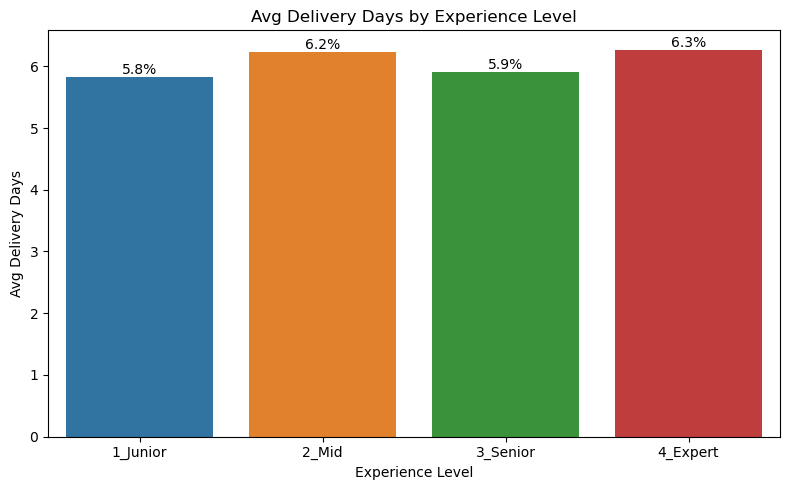

In [8]:
# Do experienced agents deliver faster?
average_delivery_days_by_experience_level = merge_df.groupby('exp_level')['delivery_days'].mean().sort_values(ascending=False).reset_index()
average_delivery_days_by_experience_level
plt.figure(figsize=(8,5))
ax = sns.barplot(data=average_delivery_days_by_experience_level,x='exp_level',y='delivery_days',order=['1_Junior','2_Mid','3_Senior','4_Expert'])
ax.bar_label(ax.containers[0],fmt='%.1f%%')
plt.title('Avg Delivery Days by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Avg Delivery Days')
plt.tight_layout()
plt.show()

In [9]:
#Which rating group has most delays?
merge_df['rating_group'] = pd.cut(merge_df['rating'],
                                 bins = [0,2.5,3.5,4.5,5],
                                 labels = ['Poor','Average','Good','Excellent'])
average_delays_by_rating = merge_df.groupby('rating_group')['delivery_days'].mean().sort_values(ascending=False).reset_index()
most_delays =average_delays_by_rating.head(1)
most_delays

,rating_group,delivery_days
0,Excellent,6.338247


In [10]:
# Best performing agents by revenue?
revenue_by_agents = merge_df.groupby(['agent_id','agent_name'])['revenue'].sum().sort_values(ascending=False).reset_index()
revenue_by_agents

,agent_id,agent_name,revenue
0,AG136,Joshua Dillon,272503.08
1,AG189,Jill Christensen,223848.33
2,AG159,James Avila,177597.57
3,AG145,Stephanie Thomas,175234.26
4,AG023,Jacqueline Cherry,167231.26
...,...,...,...
215,AG211,Marissa Castillo,22465.74
216,AG061,Michael Wilson,22243.13
217,AG062,David Cruz,21422.06
218,AG085,Michael Ali,21301.56


In [11]:
best_performing_agents = revenue_by_agents.head(1)

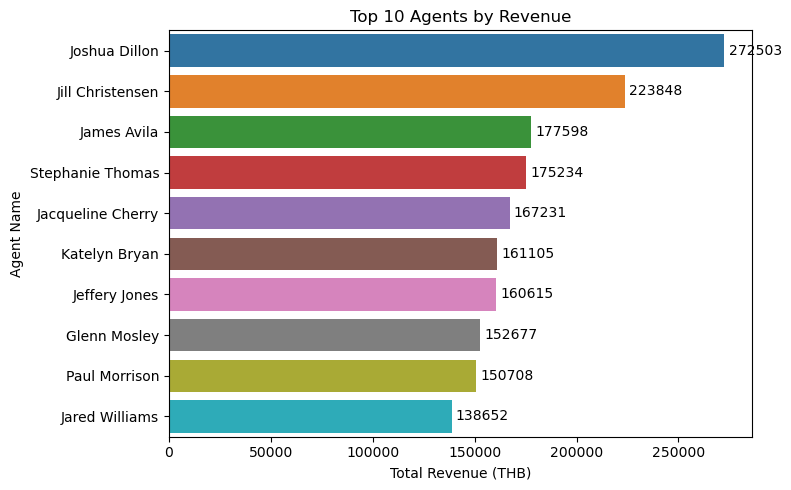

In [12]:
top_10_agents =revenue_by_agents.head(10)
top_10_agents
plt.figure(figsize=(8,5))
ax = sns.barplot(data=top_10_agents,x='revenue',y='agent_name')
ax.bar_label(ax.containers[0],padding=3)
plt.title('Top 10 Agents by Revenue')
plt.xlabel('Total Revenue (THB)')
plt.ylabel('Agent Name')
plt.tight_layout()
plt.show()

In [13]:
agent_cancel_rate = merge_df.groupby(['agent_id','agent_name'])['status'].apply(lambda x:(x=="Cancelled").sum()/len(x) * 100).sort_values(ascending=False).reset_index()
agent_cancel_rate.columns = ['agent_id','agent_name','cancel_rate_%']
agent_cancel_rate 

,agent_id,agent_name,cancel_rate_%
0,AG130,Joseph Sims,45.454545
1,AG154,Omar Taylor,41.379310
2,AG056,Joseph Anderson,40.909091
3,AG047,Alexandria Mcgee,40.000000
4,AG201,Jesus Jones,40.000000
...,...,...,...
215,AG196,John Gill,5.263158
216,AG125,Jacob Johnson,5.000000
217,AG041,Aaron Hall,4.761905
218,AG164,Terry Lane,4.545455


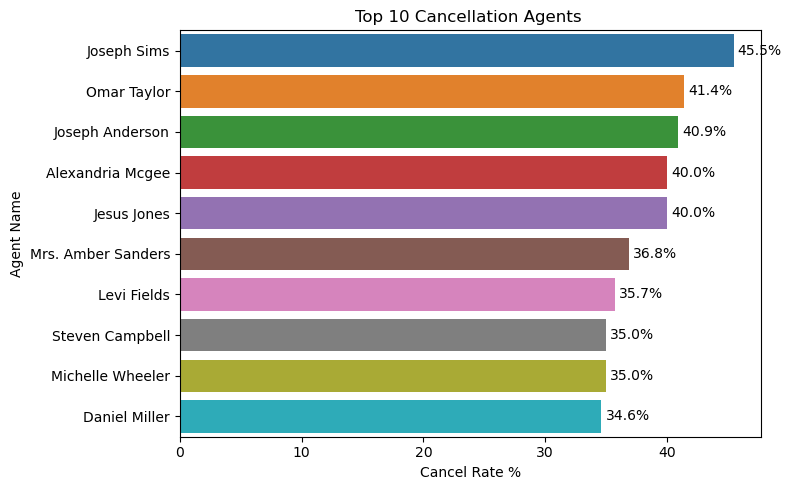

In [14]:
top_10_cancellation_agent = agent_cancel_rate.head(10)
plt.figure(figsize=(8,5))
ax = sns.barplot(data=top_10_cancellation_agent,x='cancel_rate_%',y='agent_name')
ax.bar_label(ax.containers[0],padding=3,fmt='%.1f%%')
plt.title('Top 10 Cancellation Agents ')
plt.xlabel('Cancel Rate %')
plt.ylabel('Agent Name')
plt.tight_layout()
plt.show()

In [15]:
# Which vehicle type has highest-rated agents?
avg_rating_by_vehicle =merge_df.groupby("vehicle_type_x")["rating"].mean().sort_values(ascending=False)
avg_rating_by_vehicle

vehicle_type_x
Van      3.864523
Bike     3.852727
Truck    3.837472
Name: rating, dtype: float64

In [16]:
top_vehicle_type = avg_rating_by_vehicle.head(1)
top_vehicle_type

vehicle_type_x
Van    3.864523
Name: rating, dtype: float64

In [17]:
# Low rated agents causing more cancellations ?
cancel_by_rating = merge_df.groupby("rating_group")["status"].apply(lambda x: (x == "Cancelled").sum()/len(x)*100).sort_values(ascending=False).reset_index()
cancel_by_rating.columns = ['rating_group','cancel_rate_%']
cancel_by_rating

,rating_group,cancel_rate_%
0,Excellent,20.393120
1,Average,19.033048
2,Good,18.999519
3,Poor,16.666667


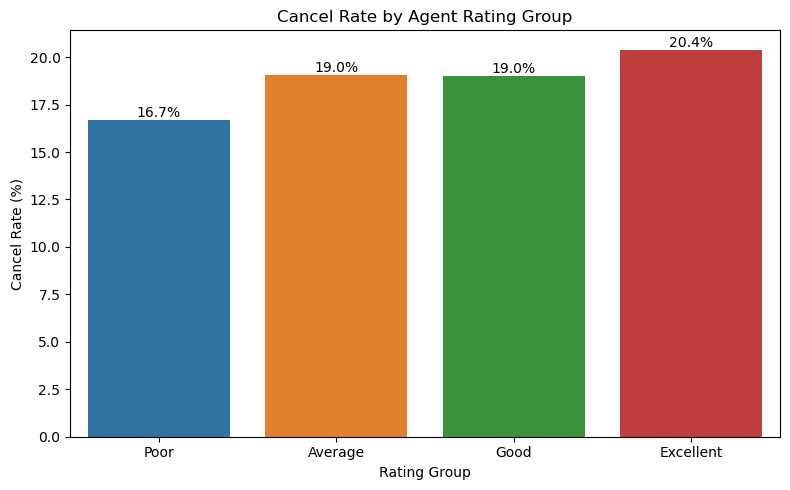

In [18]:
plt.figure(figsize=(8,5))
ax = sns.barplot(data=cancel_by_rating,x='rating_group',y='cancel_rate_%')
ax.bar_label(ax.containers[0],fmt='%.1f%%')
plt.title('Cancel Rate by Agent Rating Group')
plt.xlabel('Rating Group')
plt.ylabel('Cancel Rate (%)')
plt.tight_layout()
plt.show()

In [19]:
# Avg Agent Rating and Avg Experience
avg_agent_rating = merge_df['rating'].mean()
avg_experience = merge_df['experience_years'].mean()
print(f'Avg Agent Rating : {avg_agent_rating}')
print(f'Avg Experience : {avg_experience}')


Avg Agent Rating : 3.851849999999995
Avg Experience : 5.671020000000014


In [20]:
# Delay rate by agent
delay_rate_by_agent = (
    merge_df.groupby("agent_id")["status"]
    .apply(lambda x: (x == "Delayed").mean()*100)
    .sort_values(ascending=False).reset_index()
)

print(delay_rate_by_agent)


    agent_id     status
0      AG007  53.333333
1      AG081  46.153846
2      AG125  45.000000
3      AG030  41.176471
4      AG062  37.500000
..       ...        ...
215    AG175   4.166667
216    AG104   4.000000
217    AG206   3.703704
218    AG017   0.000000
219    AG160   0.000000

[220 rows x 2 columns]


In [21]:
# Cancellation rate by experience level
cancel_by_exp = merge_df.groupby('exp_level')['status'].apply(lambda x: (x=='Cancelled').sum()/len(x)*100).sort_values(ascending=False).reset_index()
cancel_by_exp.columns = ['exp_level','cancel_rate_%']
cancel_by_exp

,exp_level,cancel_rate_%
0,3_Senior,20.080321
1,4_Expert,19.352617
2,2_Mid,18.990203
3,1_Junior,18.750000


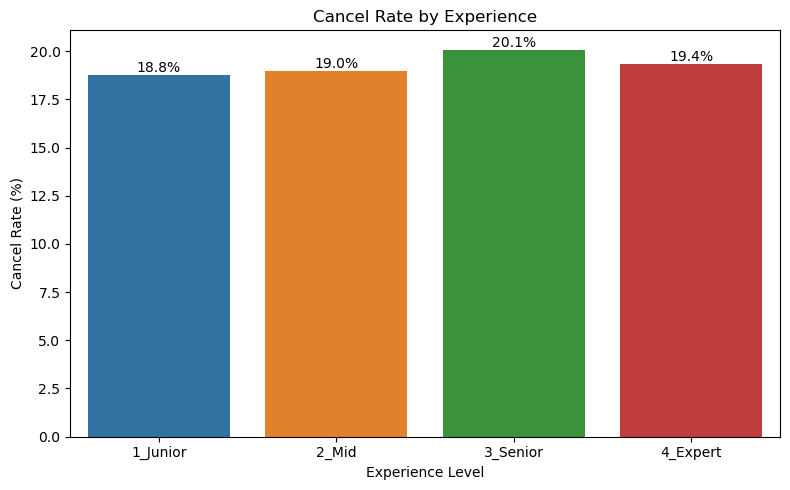

In [26]:
plt.figure(figsize=(8,5))
ax = sns.barplot(data=cancel_by_exp,x='exp_level',y='cancel_rate_%',order = ['1_Junior','2_Mid','3_Senior','4_Expert'])
ax.bar_label(ax.containers[0],fmt='%.1f%%')
plt.title('Cancel Rate by Experience')
plt.xlabel('Experience Level')
plt.ylabel('Cancel Rate (%)')
plt.tight_layout()
plt.show()

In [23]:
merge_df.to_csv('logistic_agent_merged.csv',index=False)
print(f'Exported : {merge_df.shape[0]} rows,{merge_df.shape[1]} columns')

Exported : 5000 rows,30 columns


## Agent Analysis 
-- Best Agent --

Joshua Dillon records the highest revenue.

-- Highest Cancel Rate Agent -- 

Joseph Sims records the top cancellation rate at 45.5% .

-- Experience vs Cancel --

Junior level agents have the lowest cancellation rate .

-- Rating vs Cancel --

Poor rated agent group has the lowest cancellation rate.

-- Vehicle Type -- 

Van has the highest rated vehicle.

In [24]:
print(cancel_by_exp)

  exp_level  cancel_rate_%
0  3_Senior      20.080321
1  4_Expert      19.352617
2     2_Mid      18.990203
3  1_Junior      18.750000


In [25]:
print(cancel_by_rating)

  rating_group  cancel_rate_%
0    Excellent      20.393120
1      Average      19.033048
2         Good      18.999519
3         Poor      16.666667
